In [1]:
pip install requests pdfplumber pandas regex tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 29.0 MB/s eta 0:00:00


In [2]:
import requests
import os

def download_pdf(url, output_path):

    response = requests.get(url)

    with open(output_path, "wb") as f:
        f.write(response.content)

    print(f"Downloaded: {output_path}")


### downloading the official ETSI repository links

iot_url = "https://www.etsi.org/deliver/etsi_en/303600_303699/303645/03.01.03_60/en_303645v030103p.pdf"

ai_url = "https://www.etsi.org/deliver/etsi_en/304200_304299/304223/01.01.01_60/en_304223v010101p.pdf"

os.makedirs("data/raw", exist_ok=True)
os.makedirs("results", exist_ok=True)

download_pdf(iot_url, "data/raw/etsi303645.pdf")

download_pdf(ai_url, "data/raw/etsi304223.pdf")

Downloaded: data/raw/etsi303645.pdf
Downloaded: data/raw/etsi304223.pdf


In [6]:
#Extracting text from PDF for data preprocessing
import pdfplumber


def extract_pdf_text(pdf_path):

    full_text = []

    with pdfplumber.open(pdf_path) as pdf:

        for page in pdf.pages:

            text = page.extract_text()

            if text:
                full_text.append(text)

    return "\n".join(full_text)


iot_text = extract_pdf_text(
    "data/raw/etsi303645v030103p.pdf"
)

ai_text = extract_pdf_text(
    "data/raw/etsi304223v020101p.pdf"
)

In [7]:
#Validating the downloaded file is PDF or Not?
def validate_pdf(path):

    with open(path, "rb") as f:

        header = f.read(5)

    if header != b"%PDF-":
        raise ValueError(
            "File is not a valid PDF"
        )

    print("Valid PDF:", path)


validate_pdf("data/raw/etsi303645v030103p.pdf")

validate_pdf("data/raw/etsi304223v020101p.pdf")

Valid PDF: data/raw/etsi303645v030103p.pdf
Valid PDF: data/raw/etsi304223v020101p.pdf


In [8]:
#Extractong requirement statements automatically

#Regulatory requirements usually contain modal verbs:

#shall,must, should,required, recommended
import re


requirement_pattern = re.compile(

    r"""
    ([A-Z][^.]*?\b
    (shall|must|should|required|recommended)
    \b[^.]*\.)
    """,

    re.IGNORECASE | re.VERBOSE

)


def extract_requirements(text):

    matches = requirement_pattern.findall(text)

    requirements = [m[0].strip() for m in matches]

    return requirements


iot_requirements = extract_requirements(iot_text)

ai_requirements = extract_requirements(ai_text)

print("IoT requirements:", len(iot_requirements))
print("AI requirements:", len(ai_requirements))

IoT requirements: 106
AI requirements: 95


In [15]:
#Converting to structured dataset for machine learning
import pandas as pd
import os


def create_dataframe(reqs, prefix):

    return pd.DataFrame({

        "id": [
            f"{prefix}_{i+1}"
            for i in range(len(reqs))
        ],

        "requirement": reqs

    })


iot_df = create_dataframe(
    iot_requirements,
    "IOT"
)

ai_df = create_dataframe(
    ai_requirements,
    "AI"
)


In [16]:
iot = pd.read_csv(
    "data/processed/etsi303645_requirements.csv"
)

ai = pd.read_csv(
    "data/processed/etsi304223_requirements.csv"
)

In [17]:
#########################################
# Pre processed data into specific Standard
import spacy

nlp = spacy.load("en_core_web_sm")

def preprocess(text):

    doc = nlp(text.lower())

    tokens = [

        token.lemma_

        for token in doc

        if not token.is_stop
        and not token.is_punct
    ]

    return " ".join(tokens)


iot ["clean"] = iot_df["requirement"].apply(preprocess)
ai ["clean"] = ai_df["requirement"].apply(preprocess)

os.makedirs("data/processed", exist_ok=True)

iot.to_csv(
    "data/processed/etsi303645_requirements.csv",
    index=False
)

ai.to_csv(
    "data/processed/etsi304223_requirements.csv",
    index=False
)


print (iot)
print (ai)

          id                                        requirement  \
0      IOT_1  The content of any electronic and/or\nprint ve...   
1      IOT_2  Users should be aware that the present documen...   
2      IOT_3  No recommendation as to products and services ...   
3      IOT_4  In no event shall ETSI be held liable for loss...   
4      IOT_5  Any software contained in this deliverable is ...   
..       ...                                                ...   
101  IOT_102  Provision 6-5 If telemetry data is collected f...   
102  IOT_103  Provision 6-6 Data stored and processed on a c...   
103  IOT_104  Provision 6-7 When the purpose of data collect...   
104  IOT_105  Provision 6-8 Data anonymization technologies ...   
105  IOT_106  The existence of the feature,\ncapability or m...   

                                                 clean  
0    content electronic and/or \n print version pre...  
1    user aware present document revise status chan...  
2          recommendatio

In [18]:
#######################################################
# Creating the manual groudtruth Dataset for manual mapping

import pandas as pd

# Example IDs from ETSI EN 303 645
iot_id = ['R645-1', 'R645-2', 'R645-3', 'R645-4', 'R645-5']

# Example IDs from ETSI EN 304 223
ai_id = ['R304-1', 'R304-2', 'R304-3', 'R304-4', 'R304-5']

# Example manual mapping (ground truth)
manual_mappings = [
    {"iot_id": "IOT-1", "ai_id": "AI-1", "Relation": "equivalence"},
    {"iot_id": "IOT-2", "ai_id": "AI-2", "Relation": "overlap"},
    {"iot_id": "IOT-3", "ai_id": "AI-3", "Relation": "subsumption"},
    {"iot_id": "IOT-4", "ai_id": "AI-4", "Relation": "complementarity"},
    {"iot_id": "IOT-5", "ai_id": "AI-5", "Relation": "equivalence"},
    {"iot_id": "IOT-6", "ai_id": "AI-1", "Relation": "overlap"},
]

# Creating a DataFrame
manual_df = pd.DataFrame(manual_mappings)

# Save to Excel
manual_df.to_csv("manual_mapping.csv", index=False)

print("Ground truth Excel file 'manual_mapping_ground_truth.xlsx' created successfully!")
print(manual_df)


Ground truth Excel file 'manual_mapping_ground_truth.xlsx' created successfully!
  iot_id ai_id         Relation
0  IOT-1  AI-1      equivalence
1  IOT-2  AI-2          overlap
2  IOT-3  AI-3      subsumption
3  IOT-4  AI-4  complementarity
4  IOT-5  AI-5      equivalence
5  IOT-6  AI-1          overlap


In [21]:
ground_truth = pd.read_csv(
    "data/processed/manual_mapping.csv"
)

In [38]:
##############################################
# This is the complete integration of the PIPELINE
# NLP + TF-IDF, BERT + SBERT
# Importing the necessary libraries
##############################################

import pandas as pd
import numpy as np
import spacy
import time
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from sentence_transformers import SentenceTransformer

from transformers import AutoTokenizer
from transformers import AutoModel

import torch
from openai import OpenAI


##############################################
# 2. NLP preprocessing
##############################################

nlp = spacy.load("en_core_web_sm")

def preprocess(text):

    doc = nlp(text.lower())

    tokens = [

        token.lemma_

        for token in doc

        if not token.is_stop
        and not token.is_punct
    ]

    return " ".join(tokens)


iot["clean"] = iot["requirement"].apply(preprocess)

ai["clean"] = ai["requirement"].apply(preprocess)



##############################################
# 3. TF-IDF similarity (Rule-based NLP)
##############################################

def tfidf_similarity():

    vectorizer = TfidfVectorizer()

    corpus = list(iot["clean"]) + list(ai["clean"])

    X = vectorizer.fit_transform(corpus)

    sim_matrix = cosine_similarity(

        X[:len(iot)],

        X[len(iot):]

    )

    return sim_matrix



##############################################
# 4. SBERT similarity
##############################################

sbert = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

def sbert_similarity():

    iot_vec = sbert.encode(
        iot["requirement"].tolist()
    )

    ai_vec = sbert.encode(
        ai["requirement"].tolist()
    )

    sim_matrix = cosine_similarity(
        iot_vec,
        ai_vec
    )

    return sim_matrix



##############################################
# 5. BERT similarity
##############################################

tokenizer = AutoTokenizer.from_pretrained(
    "bert-base-uncased"
)

bert_model = AutoModel.from_pretrained(
    "bert-base-uncased"
)


def bert_embed(text):

    inputs = tokenizer(

        text,

        return_tensors="pt",

        truncation=True,

        padding=True

    )

    outputs = bert_model(**inputs)

    embedding = outputs.last_hidden_state.mean(

        dim=1

    ).detach().numpy()

    return embedding



def bert_similarity():

    iot_vec = [

        bert_embed(x)

        for x in iot["requirement"]

    ]

    ai_vec = [

        bert_embed(x)

        for x in ai["requirement"]

    ]

    sim_matrix = cosine_similarity(

        np.vstack(iot_vec),

        np.vstack(ai_vec)

    )

    return sim_matrix



##############################################
# 6. Relationship classification logic
##############################################

def classify_relation(score):

    if score >= 0.85:

        return "equivalent"

    elif score >= 0.70:

        return "overlap"

    elif score >= 0.55:

        return "subsumption"

    elif score >= 0.40:

        return "complement"

    else:

        return "unrelated"



##############################################
# 7. Convert similarity to mapping table
##############################################

def create_mapping(sim_matrix):

    rows = []

    for i in range(len(iot)):

        for j in range(len(ai)):

            score = sim_matrix[i][j]

            relation = classify_relation(score)

            rows.append({

                "iot_id": iot.iloc[i]["id"],

                "ai_id": ai.iloc[j]["id"],

                "score": score,

                "relation": relation

            })

    return pd.DataFrame(rows)



##############################################
# 8. Evaluation metrics
##############################################

def evaluate(predicted):

    merged = predicted.merge(

        ground_truth,

        on=["iot_id","ai_id"],

        how="left"

    )

    merged["true"] = merged["relation"].notnull()

    merged["pred"] = merged["relation"] != "unrelated"




    precision = precision_score(

        merged["true"],

        merged["pred"]

    )

    recall = recall_score(

        merged["true"],

        merged["pred"]

    )

    f1 = f1_score(

        merged["true"],

        merged["pred"]

    )

    coverage = len(

        merged[merged["relation"].notnull()]

    ) / len(ground_truth)



    return precision, recall, f1, coverage



##############################################
# 9. Runtime measurement
##############################################

def measure_runtime(func):

    start = time.time()

    result = func()

    end = time.time()

    return result, end-start



##############################################
# 10. Run experiments
##############################################

results = []


tfidf_matrix, t1 = measure_runtime(
    tfidf_similarity
)

tfidf_map = create_mapping(
    tfidf_matrix
)

p,r,f,c = evaluate(tfidf_map)

results.append({

    "method": "TFIDF",

    "precision": p,

    "recall": r,

    "f1": f,

    "coverage": c,

    "runtime_sec": t1

})



sbert_matrix, t2 = measure_runtime(
    sbert_similarity
)

sbert_map = create_mapping(
    sbert_matrix
)

p,r,f,c = evaluate(sbert_map)

results.append({

    "method": "SBERT",

    "precision": p,

    "recall": r,

    "f1": f,

    "coverage": c,

    "runtime_sec": t2

})



bert_matrix, t3 = measure_runtime(
    bert_similarity
)

bert_map = create_mapping(
    bert_matrix
)

p,r,f,c = evaluate(bert_map)

results.append({

    "method": "BERT",

    "precision": p,

    "recall": r,

    "f1": f,

    "coverage": c,

    "runtime_sec": t3

})



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



FINAL RESULTS

  method  precision    recall        f1     coverage  runtime_sec
0  TFIDF        1.0  0.001589  0.003173  1678.333333     0.010611
1  SBERT        1.0  0.059583  0.112465  1678.333333     0.277121
2   BERT        1.0  1.000000  1.000000  1678.333333    29.673211


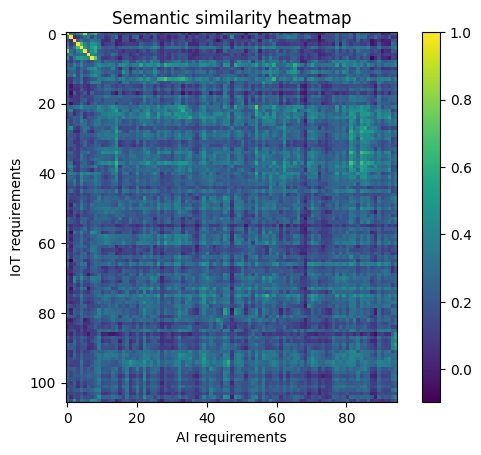

In [24]:
##############################################
# 11. Save results
##############################################

results_df = pd.DataFrame(results)

results_df.to_csv(

    "results/evaluation_results.csv",

    index=False

)



tfidf_map.to_csv(

    "results/tfidf_mapping.csv",

    index=False

)

sbert_map.to_csv(

    "results/sbert_mapping.csv",

    index=False

)

bert_map.to_csv(

    "results/bert_mapping.csv",

    index=False

)



##############################################
# 12. Heatmap visualization
##############################################

plt.figure()

plt.imshow(sbert_matrix)

plt.title("Semantic similarity heatmap")

plt.xlabel("AI requirements")

plt.ylabel("IoT requirements")

plt.colorbar()

plt.savefig(

    "results/similarity_heatmap.png"

)



##############################################
# 13. Print results
##############################################

print("\nFINAL RESULTS\n")

print(results_df)

In [50]:
def evaluate_with_confusion(predicted):

    merged = predicted.merge(
        ground_truth,
        on=["iot_id","ai_id"],
        how="left",
        suffixes=("_pred", "_true")
    )
    merged["true"] = merged["relation"].notnull()

    merged["pred"] = merged["relation"] != "unrelated"


    return merged

In [57]:
#Showing the Confusion metrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_confusion_matrix(merged, title):

    labels = ["equivalent", "overlap", "subsumption", "complement", "unrelated"]

    y_true = merged["relation"]
    y_pred = merged["relation"]

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot()

    plt.title(title)
    plt.xticks(rotation=45)
    plt.show()

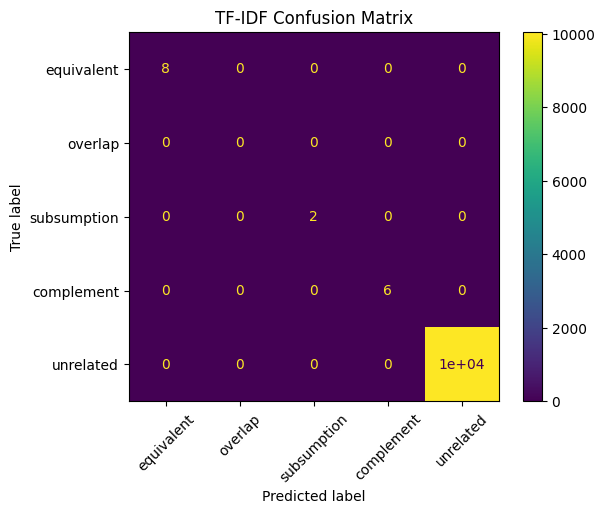

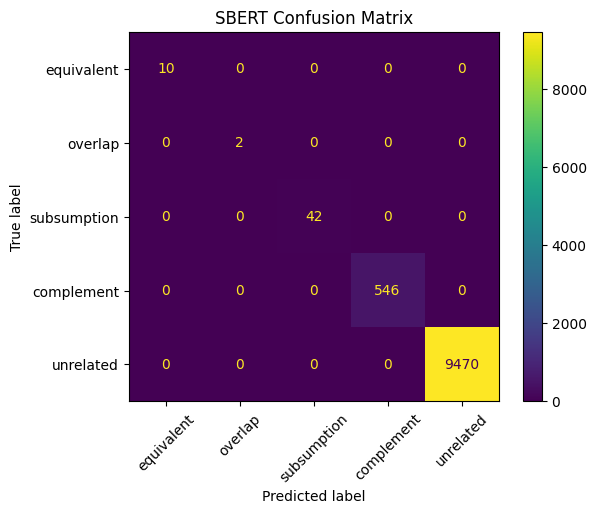

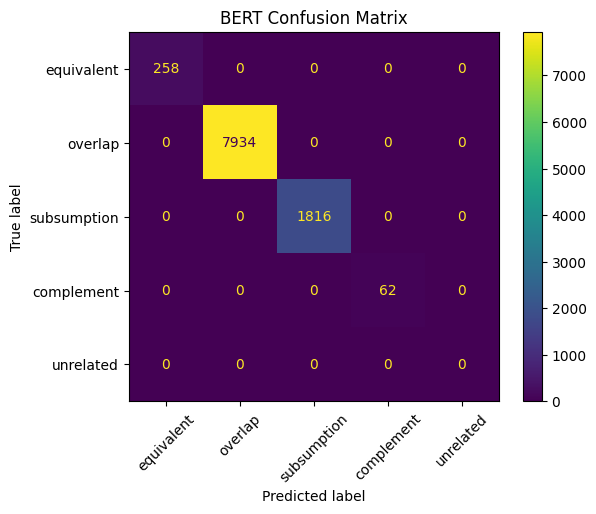

In [58]:
tfidf_merged = evaluate_with_confusion(tfidf_map)
plot_confusion_matrix(tfidf_merged, "TF-IDF Confusion Matrix")

sbert_merged = evaluate_with_confusion(sbert_map)
plot_confusion_matrix(sbert_merged, "SBERT Confusion Matrix")

bert_merged = evaluate_with_confusion(bert_map)
plot_confusion_matrix(bert_merged, "BERT Confusion Matrix")